#### 과일 Data를 CNN으로 Image 분류

In [36]:
import numpy as np
fruits = np.load("../Data/fruits.npy")
fruits.shape

(300, 100, 100)

In [37]:
# Target 만들기
target = np.concatenate(
    [
        np.zeros(100), # Apple
        np.ones(100), # pineapple
        np.full(100, 2) # banana
    ]
)
target.shape

(300,)

In [38]:
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2.

----
#### train와 test

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
train = fruits.reshape(-1, 100, 100, 1) / 255.0 # (-1, 크기, 크기, 1)

train_data, test_data, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

train_data, val_data, train_target, val_target = \
    train_test_split(
        train_data, 
        train_target, 
        test_size=0.2, 
        random_state=42
    )

In [41]:
# 크기 확인
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(192, 100, 100, 1)
(60, 100, 100, 1)
(192,)
(60,)


#### CNN 만들기

In [42]:
from tensorflow import keras

In [43]:
model = keras.Sequential()

In [44]:
model.add(
    keras.layers.Conv2D(
        32, # Filter의 갯수
        kernel_size=3, # 보통 정사각형으로 구성
        activation='relu', # 활성화 함수
        padding='same', #valid
        input_shape=(100, 100, 1)
    )
)

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 풀링층
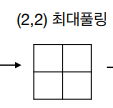

In [45]:
# Pooling
model.add(
    keras.layers.MaxPool2D(2) # 2*2 max pooling
)

#### 두번째 합성곱층

In [46]:
model.add(
    keras.layers.Conv2D(
        64, # Filter의 갯수 (32, 64, 128, 256...)
        kernel_size=3, # 보통 정사각형으로 구성
        activation='relu', # 활성화 함수
        padding='same' #valid
    )
)

# Pooling
model.add(
    keras.layers.MaxPool2D(2) # 2*2 max pooling
)

#### Dense층

In [47]:
# 입력층
model.add(
    keras.layers.Flatten()
)

#은닉층
model.add(
    keras.layers.Dense(
        100,
        activation='relu'
    )
)

# Dropout 층
model.add(
    keras.layers.Dropout(0.5)
)

# 출력층
model.add(
    keras.layers.Dense(
        3,
        activation='softmax'
    )
)

In [48]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │     4,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,019,219 (15.33 MB)

 Trainable params: 4,019,219 (15.33 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Compile

In [49]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_fruits.keras")

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

In [50]:
history = model.fit(
    train_data,
    train_target,
    epochs = 20,
    validation_data=(val_data, val_target),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/20


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.5365 - loss: 0.9320 - val_accuracy: 0.9375 - val_loss: 0.4870
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.9531 - loss: 0.3299 - val_accuracy: 1.0000 - val_loss: 0.0720
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 1.0000 - loss: 0.0522 - val_accuracy: 1.0000 - val_loss: 0.0111
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 1.0000 - loss: 0.0126 - val_accuracy: 1.0000 - val_loss: 2.5983e-04
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.9948 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 2.0327e-04
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 1.7259e-04
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.9896 - loss: 0.0215 - val_accuracy: 1.0000 - val_loss: 7.3815e-04
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - val_

#### 평가와 예측

In [57]:
model.evaluate(train_data, train_target)
model.evaluate(val_data, val_target)
model.evaluate(test_data, test_target)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 3.2901e-05
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 2.3726e-05
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 4.5444e-05


[4.5444219722412527e-05, 1.0]

#### 이미지로 확인하기

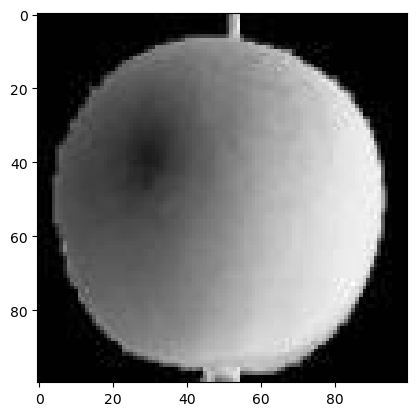

In [53]:
import matplotlib.pyplot as plt

plt.imshow(
    val_data[0].reshape(100, 100),
    cmap='gray'
)
plt.show()

In [54]:
pred = model.predict(
    val_data[:1]
)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([[9.9996924e-01, 3.0808431e-05, 4.3794145e-08]], dtype=float32)

In [55]:
# 글자로 변경하기
import numpy as np
classes = ['사과', '파인애플', '바나나']
len(classes)

3

In [56]:
classes[np.argmax(pred)]

'사과'